# Notebook for defining, training and sampling from the model

### Author Daniel Lomholt Christensen

As far as I am aware, this only requires the `mcpltool` software to run, along with matplotlib, pytorch and numpy

In [11]:
# Load the relevant libraries
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import mcpl
import matplotlib.pyplot as plt


In [7]:
# Data processing steps.
def load_mcpl_file(
    filepath: str, n_particles: int, offset: int = 0, print_status: bool = False
):
    mcplfile = mcpl.MCPLFile(filepath)
    data = np.zeros([n_particles, 7], dtype=np.float32)

    for i, p in enumerate(mcplfile.particles):
        if i < offset:
            continue
        if i % 10000 == 0 and print_status == True:
            print(f"Loading particles. {i - offset} currently loaded.")
        j = i - offset
        data[j : (j + 1), 0] = np.asarray(p.weight)
        data[j : (j + 1), 1] = np.asarray(p.ekin)
        data[j : (j + 1), 2:5] = np.asarray([p.ux, p.uy, p.uz]).T
        data[j : (j + 1), 5:] = np.asarray([p.x, p.y]).T
        if j >= n_particles + offset:
            break
    return torch.tensor(data, dtype=torch.float32)


def dim_reduction(data):
    out = torch.zeros((data.shape[0], 6))
    out[:, 0:2] = data[:, 0:2]
    ux, uy, uz = data[:, 2], data[:, 3], data[:, 4]
    theta = torch.atan2(torch.sqrt(ux * ux + uy * uy), uz)
    phi = torch.atan2(uy, ux)
    out[:, 2] = theta
    out[:, 3] = phi
    out[:, 4:] = data[:, 5:7]
    return out


def normalize(data):
    # Normalizes between 0 and 1
    xmin = data.min()
    xmax = data.max()
    dx = xmax - xmin
    data = (data - xmin) / dx
    return data, xmin, dx


def preprocess_nn(data):
    data = dim_reduction(data)
    mins = np.zeros((data.shape[1]))
    dxs = np.zeros((data.shape[1]))
    data[:, 0] = torch.log(data[:, 0]*1e20 + 1)  # weight
    data[:, 1] = torch.log(data[:, 1]*1e10 + 1)  # energy
    for i in range(data.shape[1]):
        data[:, i], mins[i], dxs[i] = normalize(data[:, i])
    return data, mins, dxs


def inverse_norm(data, min, dx):
    data = data * dx + min
    return data


def postprocess_nn(data, mins=None, dxs=None, filename=""):
    if filename != "":
        mins, dxs = np.load(filename)
    for i in range(data.shape[1]):
        data[:, i] = inverse_norm(data[:, i], mins[i], dxs[i])
    output = torch.zeros((data.shape[0], 7))
    output[:, 0] = (np.exp(data[:, 0]) - 1)/1e20
    output[:, 1] = (np.exp(data[:, 1]) - 1)/1e10

    output[:, 2] = np.cos(data[:, 3]) * np.sin(data[:, 2])
    output[:, 3] = np.sin(data[:, 3]) * np.sin(data[:, 2])
    output[:, 4] = np.cos(data[:, 2])
    output[:, 5:] = data[:, 4:]

    return output

In [8]:
# Define the model

class VelocityField(nn.Module):
    def __init__(self, input_dim=6, start = 12, mid = 512, network_dimensions=512):
        super().__init__()
        self.t_dim = input_dim
        self.apply_model = nn.Sequential(
                nn.Linear(start, start * 2),
                nn.LeakyReLU(),
                nn.Linear(start * 2, start * 2**2),
                nn.LeakyReLU(),
                nn.Linear(start * 2**2, start * 2**3),
                nn.LeakyReLU(),
                nn.Linear(start * 2**3, start * 2**4),
                nn.LeakyReLU(),
                nn.Linear(start * 2**4, 512),
                nn.LeakyReLU(),
                nn.Linear(512, 512),
                nn.LeakyReLU(),
                nn.Linear(512, start * 2**4),
                nn.LeakyReLU(),
                nn.Linear(start * 2**4, start * 2**3),
                nn.LeakyReLU(),
                nn.Linear(start * 2**3, start * 2**2),
                nn.LeakyReLU(),
                nn.Linear(start * 2**2, start * 2),
                nn.LeakyReLU(),
                nn.Linear(start * 2, input_dim)
        )

    def time_embed(self, t, max_positions=10000):
        # Embed t into a trigonometric space. Half of inputs are cosine, other half are sine
        t = t.squeeze(-1) * max_positions
        half_dim = self.t_dim // 2
        emb = math.log(max_positions) / (half_dim - 1)
        emb = torch.arange(half_dim, device=t.device).float().mul(-emb).exp()
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        if self.t_dim % 2 == 1:  # zero padding
            emb = nn.functional.pad(emb, (0, 1), mode="constant")
        return emb

    def forward(self, x, t):
        # Embed time t (shape: [batch_size, 1]) into a higher-dimensional vector
        t_embed = self.time_embed(t)
        x = torch.column_stack((x, t_embed))
        x = self.apply_model(x)
        return x

In [9]:
def flow_matching_loss(model, x0, x1, t):
    # Interpolate path
    xt = (1 - t) * x0 + t * x1

    # True velocity for straight-line FM
    v_target = x1 - x0

    # Model velocity
    v_pred = model(xt, t)
    # MSE
    loss = ( ((v_pred - v_target) ** 2).mean(dim=-1)).mean()

    return loss


# ---------------------------------------------------------
#  Training loop
# ---------------------------------------------------------
def train(
        model,
        dataset,
        filename,
        device="mps",
        steps=100000,
        lr=1e-3,
        batch_size=256
        ):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_loss = float('inf')
    best_state = None

    losses = []

    N = dataset.shape[0]
    for step in range(steps):
        idx = torch.randint(0, N, (batch_size,))
        x0 = torch.randn(batch_size, dataset.shape[1]).to(device)
        x1 = dataset[idx].to(device)
        t = torch.rand(batch_size, 1).to(device)
        loss = flow_matching_loss(model, x0, x1, t)

        # Make the loss, an average of more than 1 step
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

        if loss.item() < best_loss:
            best_loss = loss.item()
            print(f"Saving the best model at step {step}, with loss {best_loss:.2g}")
            best_state = {"state_dict": model.state_dict(),
                          "loss": loss.item()}
            torch.save(best_state, filename)
        if step % 500 == 0:
            print(f"step {step}: loss {loss.item():.4g}")

    return losses


# ---------------------------------------------------------
# USAGE
# ---------------------------------------------------------
n_particles = int(1e6)

data = load_mcpl_file("../ODIN.mcpl.gz", n_particles)
data, mins, dxs = preprocess_nn(data)
np.save("normalization_params.npy", np.array([mins, dxs]))
dim = data.shape[1]
device = "mps"
filename = "flowmodel.pth"
model = VelocityField().to(device)

losses = train(model, data, filename)

np.save("losses.npy", np.array(losses))

Saving the best model at step 0, with loss 1.4
step 0: loss 1.403
Saving the best model at step 2, with loss 1.3
Saving the best model at step 5, with loss 1.3
Saving the best model at step 6, with loss 1.3
Saving the best model at step 7, with loss 1.3
Saving the best model at step 9, with loss 1.3
Saving the best model at step 15, with loss 1.2
Saving the best model at step 16, with loss 1.2
Saving the best model at step 18, with loss 1.1
Saving the best model at step 19, with loss 1.1
Saving the best model at step 20, with loss 1
Saving the best model at step 25, with loss 0.97
Saving the best model at step 34, with loss 0.96
Saving the best model at step 41, with loss 0.95
Saving the best model at step 47, with loss 0.93
Saving the best model at step 48, with loss 0.92
Saving the best model at step 87, with loss 0.89
Saving the best model at step 113, with loss 0.83
Saving the best model at step 162, with loss 0.82
Saving the best model at step 170, with loss 0.81
Saving the best m

KeyboardInterrupt: 

In [13]:
def plot_correlations_7d(data, title="", filename=""):
    labels = [
        "Weight [a.u]",
        "Energy [MeV]",
        "Direction x",
        "Direction y",
        "Direction z - 1",
        "Position x [cm]",
        "Position y [cm]",
    ]
    # labels = ["Angle theta", "Angle phi", "Position x", "Position y"]
    input_dim = 7
    
    plot_data = torch.asarray(data, copy=True)
    print(plot_data[0])
    plot_data[:,4] -= 1
    print(plot_data[0])
    fig, ax = plt.subplots(ncols=input_dim, nrows=input_dim, figsize=(20,20))
    for i in range(input_dim):
        for j in range(input_dim):
            if j > i:
                ax[i, j].set_axis_off()
                continue
            if j == i:
                try:
                    ax[i, j].hist(plot_data[:, i], bins=50)
                    ax[i, j].set(xlabel=labels[i], ylabel="Counts")
                except Exception as e:
                    print(e)
                    ax[i, j].set_axis_off()
                continue
            ax[i, j].hist2d(plot_data[:, i], plot_data[:, j], bins=100)
            ax[i, j].set(xlabel=labels[i], ylabel=labels[j])
    fig.suptitle(title)
    fig.tight_layout()
    if filename != "":
        fig.savefig(filename, dpi=300)

def sample_flow(model, n_samples, device="mps", t_steps=1000):
    """
    Evolve x0 through the learned flow to produce a sample from p1.
    """
    xt = torch.randn(n_samples, 6, device=device)
    with torch.no_grad():
        for i, t_val in enumerate(torch.linspace(0, 1, t_steps, device=device), start=1):
            if i % 100 == 0:
                print(f"Generating samples. At time step {i}")
            pred = model(xt, t_val.expand(n_samples, 1))
            xt = xt + (1 / t_steps) * pred
    return xt


plot = True
loss = False
n_samples = int(1e5)
batch_size = 1000
n_samples = int(n_samples)
device = "mps"


ckpt = torch.load("flowModel.pth", map_location=device)
loss = ckpt["loss"]
print(f"Loaded model showed a loss of {loss} on its batch")

nf = VelocityField().to(device)
nf.load_state_dict(ckpt["state_dict"])
nf.eval()

lims = np.load("../limits.npy") 


mins = torch.asarray(lims[0], dtype=torch.float32, device="cpu")
maxs = torch.asarray(lims[1], dtype=torch.float32, device="cpu")


samples = []
while len(samples) < n_samples:
    print(len(samples))
    # Limit samples to within the preprocessed data limits
    batch = sample_flow(nf, min([100_000, n_samples])).cpu()
    batch = postprocess_nn(batch, filename="normalization_params.npy")
    mask = (batch >= mins) & (batch <= maxs)
    batch = batch[mask.all(axis=1)]
    samples = samples + batch.tolist()
samples = samples[:n_samples]
samples = torch.asarray(samples)

print(f"Actually plotted samples = {samples.shape[0]}")


Loaded model showed a loss of 0.2750331163406372 on its batch
0
Generating samples. At time step 100
Generating samples. At time step 200
Generating samples. At time step 300
Generating samples. At time step 400
Generating samples. At time step 500
Generating samples. At time step 600
Generating samples. At time step 700
Generating samples. At time step 800
Generating samples. At time step 900
Generating samples. At time step 1000


/var/folders/m8/f330x_5d5lvdrkc5f7qn2b1h0000gn/T/ipykernel_3251/1532567129.py:66: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  output[:, 0] = (np.exp(data[:, 0]) - 1)/1e20
/var/folders/m8/f330x_5d5lvdrkc5f7qn2b1h0000gn/T/ipykernel_3251/1532567129.py:67: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  output[:, 1] = (np.exp(data[:, 1]) - 1)/1e10
/var/folders/m8/f330x_5d5lvdrkc5f7qn2b1h0000gn/T/ipykernel_3251/1532567129.py:69: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  output[:, 2] = np.cos(data[:, 3]) * np.sin(data[:, 2])
/var/folders/m8/f330x_5d5lvdrkc5f7qn2b1h0000gn/T/ipykernel_3251/1532567129.py:70: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. 

69429
Generating samples. At time step 100
Generating samples. At time step 200
Generating samples. At time step 300
Generating samples. At time step 400
Generating samples. At time step 500
Generating samples. At time step 600
Generating samples. At time step 700
Generating samples. At time step 800
Generating samples. At time step 900
Generating samples. At time step 1000
Actually plotted samples = 100000


tensor([ 1.5292e-03,  2.2628e-08, -1.4660e-03, -4.8876e-04,  1.0000e+00,
        -9.3330e-02, -3.1522e-01])
tensor([ 1.5292e-03,  2.2628e-08, -1.4660e-03, -4.8876e-04, -1.1921e-06,
        -9.3330e-02, -3.1522e-01])


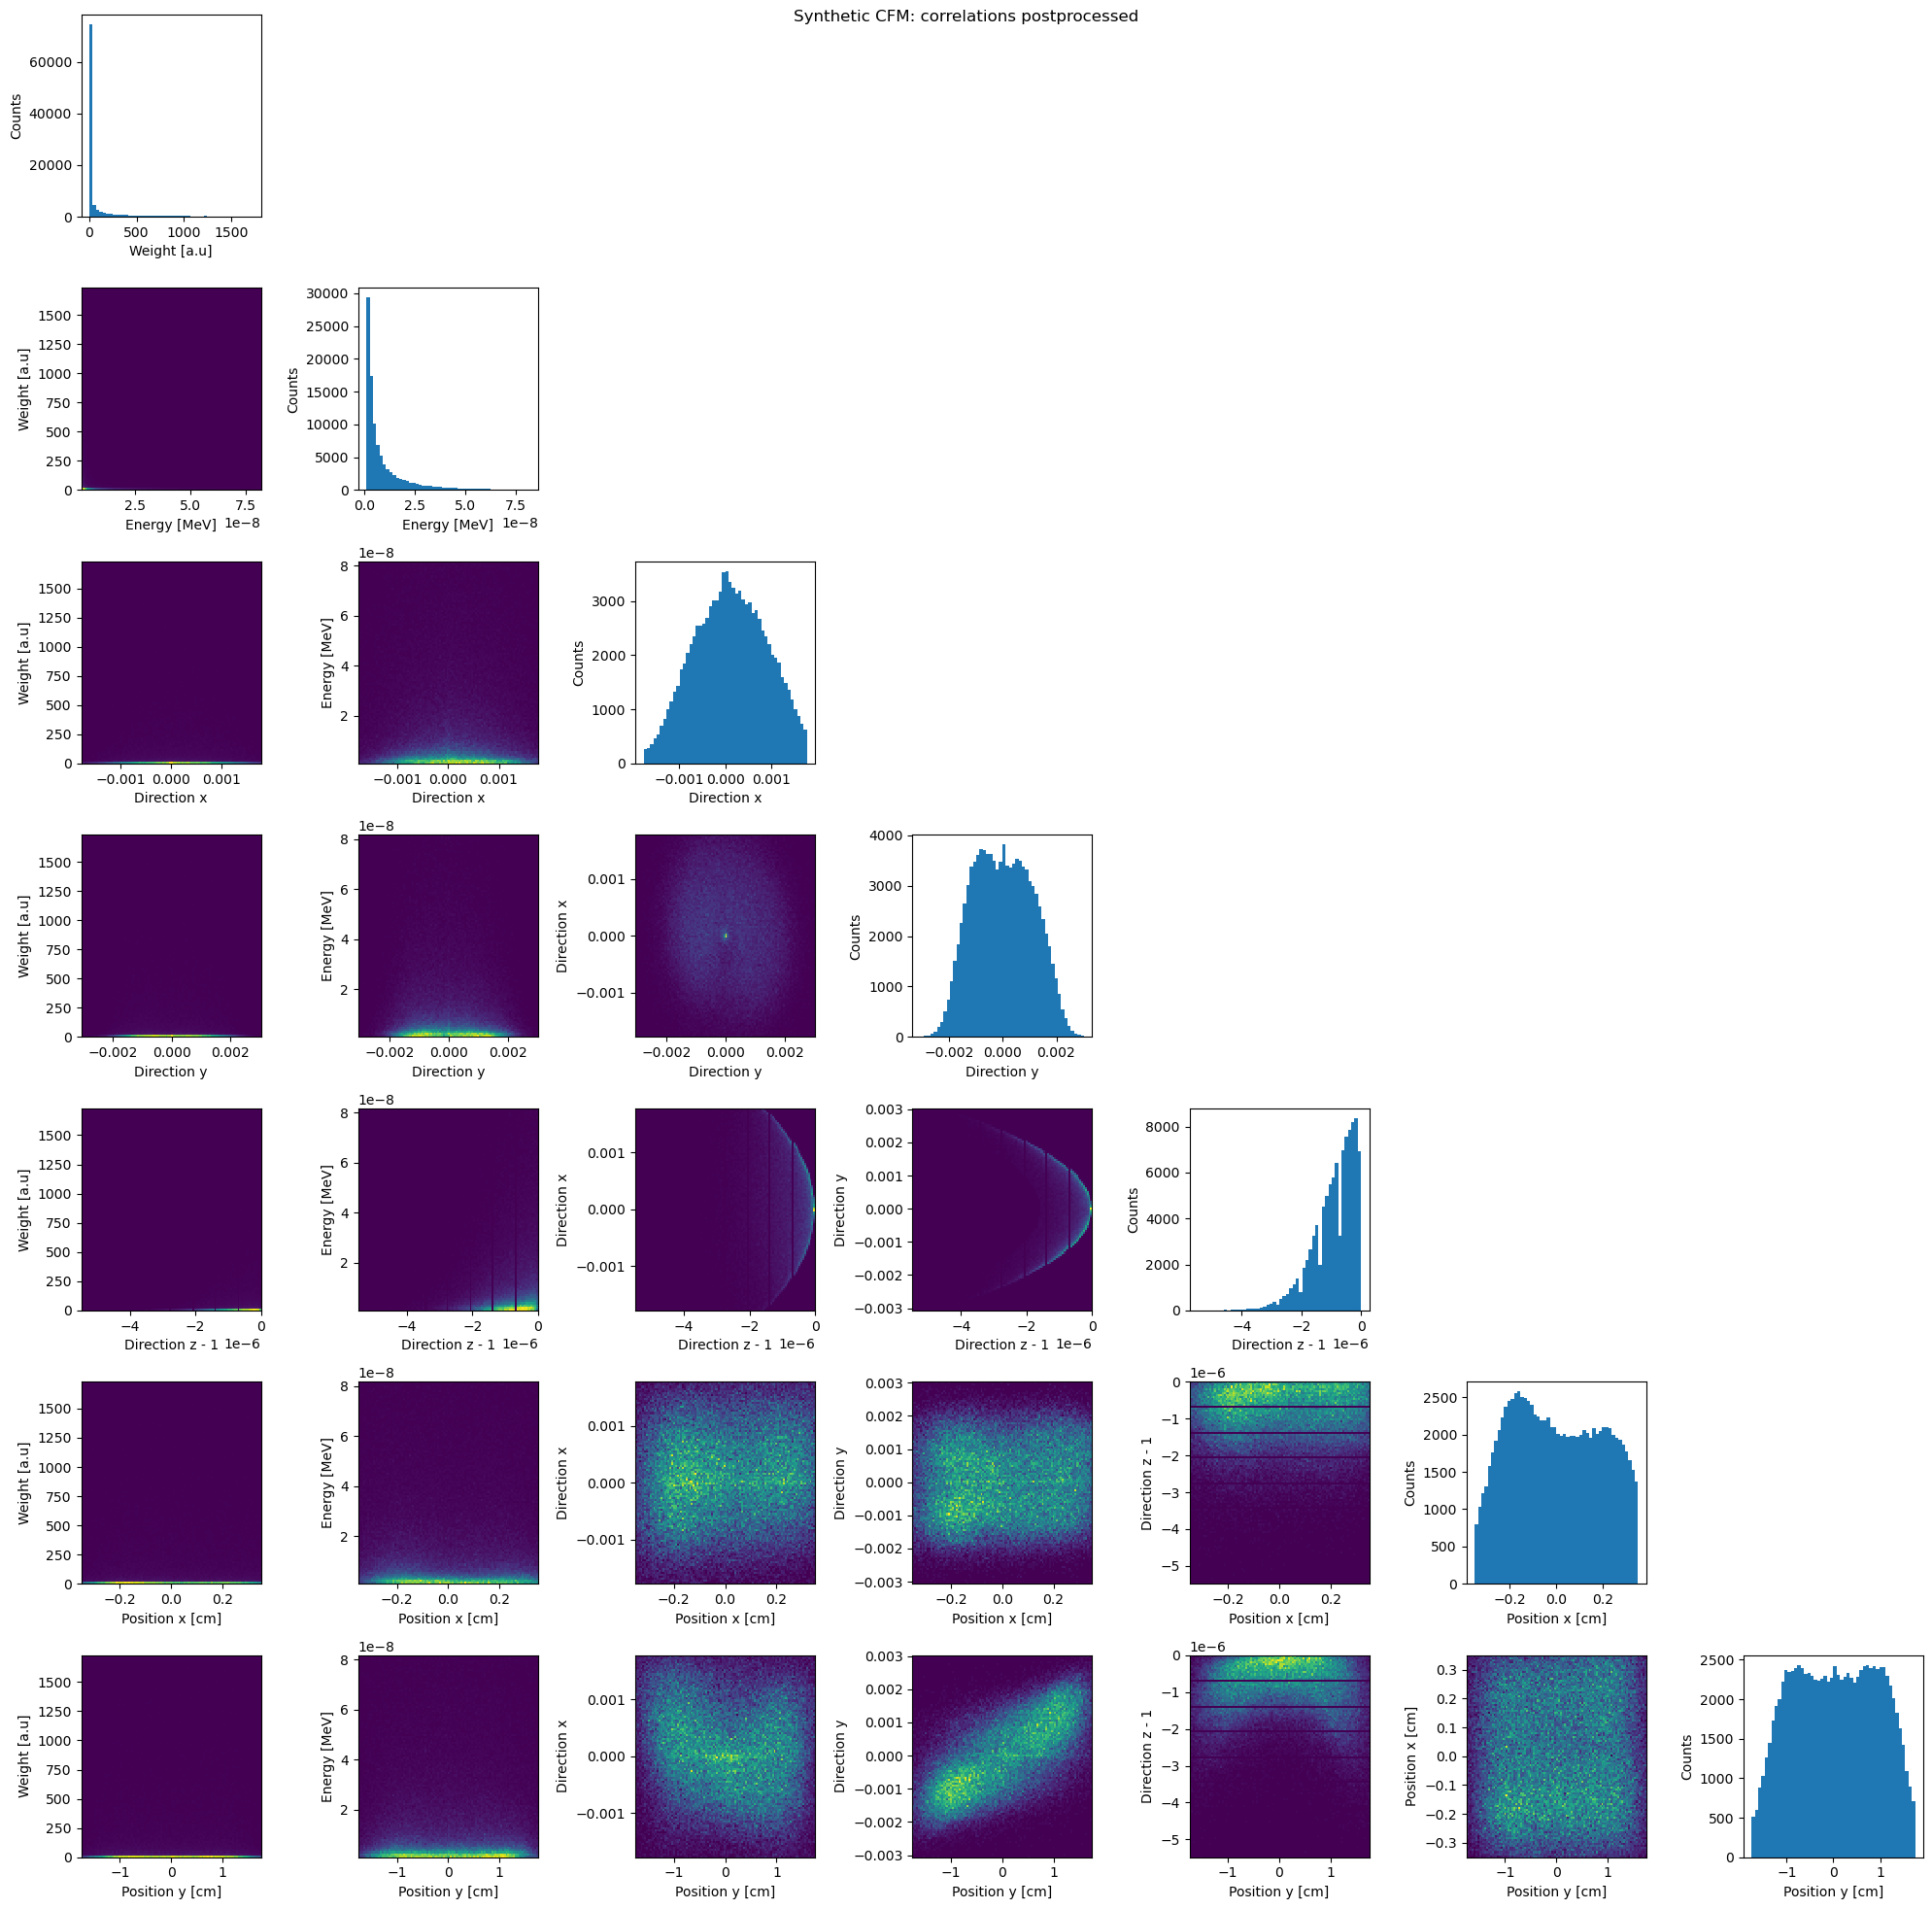

In [14]:

if plot:
    plot_correlations_7d(samples, "Synthetic CFM: correlations postprocessed")

# Saving the data requires the np2mcpl package
# save_data_as_mcpl(samples, "../cmf_samples")
plt.show()